# **Importing Libraries Needed For RNN Work**

### Imports — Quick Meaning

- numpy → math + arrays (number grids)
- tensorflow + keras → the DL engine + friendly front-end

### Data Prep Tool

- TextVectorization → turns words into numbers (word IDs) **and** pads sentences to the same length — all in one step. It scans your sentences, builds a vocabulary (e.g., "love" → 3), and outputs fixed-size number sequences like [4, 12, 7, 0, 0]. It's the modern replacement for Tokenizer + pad_sequences, and it lives **inside the model** as a layer.

### Model Building Blocks

- Input → the **entry point** — defines the shape of the data coming into the model. Tells Keras: "expect sequences of word IDs here." Needed when using the functional API (Model), where you explicitly wire inputs to outputs.
- Model → the **blueprint** — lets you design how layers connect (not just stack them). Gives you full control over inputs and outputs.
- Embedding → **word → vector** — turns word IDs into dense number vectors (e.g., 3 → [0.2, -0.5, 0.8]) so the model can understand meaning, not just IDs.
- SimpleRNN → the **memory layer** — reads the sequence step by step, keeps a hidden state (feedback loop), and passes context forward in time.
- Dense → the **decision layer** — takes the RNN's final memory and outputs the final answer (e.g., positive = 1, negative = 0).

In [55]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Input
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# **Creating Dummy Data**

### What we're doing
- `sentences = [...]` → a list of **30 short reviews**, in plain English
- First 15 are **positive** ("love", "great", "amazing")
- Last 15 are **negative** ("hate", "awful", "worst")
- `labels = [1]*15 + [0]*15` → 15 ones (positive) + 15 zeros (negative)
- `labels = np.array(labels)` → convert to NumPy so Keras/TensorFlow can use it

### Why we do this
- We need **input (X) + correct answers (y)** to train any model
- Since we're just learning, we hand-make a tiny clean dataset instead of downloading a real one
- The sentences are **obviously positive or negative** → the model can easily learn the pattern
- Labels must be **numbers** (1 / 0) because models only learn from math, not words

### Label convention (memorize this)
- `1` → Positive 😊
- `0` → Negative 😞

### Mental picture

- Text input → model → prediction (0 or 1)

- `↑ ↑`


- X (sentences) y (labels = correct answers)

In [56]:
sentences: list[str] = [
 "I love this product",
 "This movie made me smile",
 "Service was friendly and quick",
 "Today felt bright and happy",
 "This is the best day",
 "Absolutely fantastic experience",
 "I enjoyed every single moment",
 "Great job, well done",
 "The food tasted delicious",
 "Totally recommend to everyone",
 "Very satisfied with results",
 "This worked better than expected",
 "Amazing quality and value",
 "Such a pleasant surprise",
 "I feel positive about this",
 "I hate this product",
 "This movie bored me",
 "Service was rude and slow",
 "Today was cold and lonely",
 "This is the worst day",
 "Terrible experience overall",
 "I regret buying this",
 "Very disappointed with results",
 "The food tasted awful",
 "Do not recommend this",
 "It broke after one use",
 "Not worth the money",
 "Utterly frustrating and annoying",
 "I feel negative about this",
 "Such a waste of time",
]
labels: list[int] = [1]*15 + [0]*15
labels: np.array = np.array(labels)

## **Creating the Vectorizer**

- vocab_size = 2000 → max number of unique words to remember
- max_word_sentence = max(len(s.split()) for s in sentences) → finds the **longest sentence by word count** (using .split() counts words, not characters). This becomes our output_sequence_length.
- TextVectorization(...) → builds the layer that turns words → numbers
- vectorizer.adapt(sentences) → scans sentences to build the vocabulary

### Inspecting What the Vectorizer Learned

- vectorizer.get_vocabulary() → returns the **list of words** it kept, ordered by frequency. Index 0 is the padding slot, index 1 is the unknown-word slot, then real words start.
- vectorizer(sentences).numpy() → runs every sentence through the layer and shows the **final padded number sequences** — each sentence becomes a fixed-length list of word IDs, with zeros added at the end to fill the gap.

### Why we print these

- **Vocabulary** → confirms the layer actually learned your words (you should see love, hate, movie, etc.)
- **Padded Sequences** → lets you *see* the numbers the model will actually train on — no more guessing what's inside.
- The zeros at the end = padding. The model learns to ignore them.

### Why we used .split() instead of len(s)

- len("I love this") → **11** (counts characters)
- len("I love this".split()) → **3** (counts words)
- RNNs work with **tokens (words)**, not characters → so we split first.

### Creating X and y

- X = vectorizer(sentences).numpy() → a **2D NumPy array**, shape (30, 5) — 30 sentences × 5 word IDs each (zero-padded)
- y = labels → a **1D NumPy array**, shape (30,) — 15 ones (positive) + 15 zeros (negative)
- Both are NumPy arrays (via .numpy() and np.array) → ready to feed into the model
- X goes into the Embedding layer → SimpleRNN → Dense → outputs 0 or 1

### Type hints

- X → typed as np.ndarray
- y → typed as np.ndarray
- Both are arrays, not Python lists, so the correct hint is np.ndarray

In [57]:
vocab_size: int = 2000
max_word_sentence: int = max(len(s.split()) for s in sentences)

vectorizer: TextVectorization = TextVectorization(
    max_tokens=vocab_size,
    output_sequence_length=max_word_sentence
)

vectorizer.adapt(sentences)
max_word_sentence

5

In [58]:
X: np.ndarray = vectorizer(sentences).numpy()
y: np.ndarray = labels

In [59]:
print(X)
print(f'\n\n\n{y}')

[[ 3 57  2 15  0]
 [ 2 17 56 18 40]
 [12  6 65  4 46]
 [ 9 66 79  4 62]
 [ 2 19  5 82 23]
 [87 67 22  0  0]
 [ 3 71 70 42 55]
 [63 59 29 72  0]
 [ 5 20 10 75  0]
 [34 14 35 69  0]
 [ 8 43  7 13  0]
 [ 2 28 81 37 68]
 [85 47  4 31  0]
 [11 25 49 39  0]
 [ 3 21 48 24  2]
 [ 3 61  2 15  0]
 [ 2 17 80 18  0]
 [12  6 44  4 41]
 [ 9  6 76  4 58]
 [ 2 19  5 27 23]
 [38 22 50  0  0]
 [ 3 45 77  2  0]
 [ 8 74  7 13  0]
 [ 5 20 10 83  0]
 [73 16 14  2  0]
 [60 78 86 51 33]
 [16 26  5 54  0]
 [32 64  4 84  0]
 [ 3 21 53 24  2]
 [11 25 30 52 36]]



[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# **Creating RNN Model**

### Setup — Model Hyperparameters

- embed_dim = 16 → each word becomes a 16-number vector
- rnn_units = 8 → size of the RNN's hidden state (memory width)

### Input — Declaring the Entry Shape

- inp = Input(shape=(max_word_sentence,), dtype="int32")
- Tells the model: "each sample = 5 word IDs (integers)"
- Functional API needs an explicit entry point before wiring layers

### Embedding — Word IDs → Vectors

- input_dim = vocab_size → 2000 possible words (rows in the lookup table)
- output_dim = embed_dim → each word → 16-number vector
- mask_zero = True → skip padding zeros so they don't pollute the hidden state
- Output shape so far: (batch, 5, 16)

### SimpleRNN — The Memory Layer

- units = rnn_units → 8 hidden numbers (memory width)
- return_sequences = False → only return the last hidden state, not all 5 steps
- return_state = False → don't return the internal state separately
- Output shape: (batch, 8)

### Dense — The Decision Layer

- Dense(1, activation='sigmoid') → one output neuron, sigmoid squishes to 0–1
- Output = probability of positive sentiment
- Output shape: (batch, 1)

### Model — Wiring Inputs to Outputs

- Model(inputs=inp, outputs=out) → connects the graph
- Note: plural "inputs" / "outputs" (common typo: "input" / "output")

### Compile — Configuring Training

- optimizer='adam' → adaptive gradient descent
- loss='binary_crossentropy' → correct loss for 0/1 classification
- metrics=['accuracy'] → track accuracy during training

### Architecture at a Glance

    Input (5,) → Embedding (5, 16) → SimpleRNN (8,) → Dense (1,) → sigmoid

### Shapes Flow

- Input:         (None, 5)
- After Embed:   (None, 5, 16)
- After RNN:     (None, 8)
- After Dense:   (None, 1)
- Final output = probability (0 to 1)

In [60]:
embed_dim: int = 16
rnn_units: int = 8

In [61]:
inp: Input = Input(
    shape=(max_word_sentence,),
    dtype="int32",
    name='input'
)

In [62]:
x: Embedding = Embedding(
    input_dim=vocab_size,
    output_dim=embed_dim,
    mask_zero=True,
    name='embed'
)(inp)

In [63]:
rnn: SimpleRNN = SimpleRNN(
    units=rnn_units,
    return_sequences=False,
    return_state=False,
    name='simple_rnn'
)

In [64]:
x_last: tf.Tensor = rnn(x)

In [65]:
out = Dense(1, activation='sigmoid', name='out')(x_last)

In [66]:
model: Model = Model(
    inputs=inp,
    outputs=out
)

In [67]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# **Model Summary — Explained**

### What `model.summary()` shows

A table of every layer in your model: its type, output shape, parameter count, and what it's connected to. This is how you verify the model is wired correctly before training.

### Reading the Table

- **Layer (type)** → name + class of the layer

- **Output Shape** → tensor shape after that layer runs (None = batch size, filled at runtime)

- **Param #** → number of learnable weights in that layer

- **Connected to** → which previous layer(s) feed into it

---

### Layer-by-Layer Breakdown

**1. input (InputLayer)**
- Output shape: (None, 5)
- Params: 0
- Role: entry point — declares 5 word IDs per sample
- No weights — it just defines shape

**2. embed (Embedding)**
- Output shape: (None, 5, 16)
- Params: 32,000
- Where 32,000 comes from: vocab_size (2000) × embed_dim (16) = 32,000
- This is a lookup table: 2000 rows, each row is a 16-number vector

**3. not_equal (NotEqual)**
- Output shape: (None, 5)
- Params: 0
- Role: computes the padding mask (checks which values ≠ 0)
- Created automatically because you set mask_zero=True in the Embedding
- No weights — it's a math operation, not a learning layer

**4. simpe_rnn (SimpleRNN)**
- Output shape: (None, 8)
- Params: 200
- Where 200 comes from:
  - Input weights: 16 × 8 = 128
  - Hidden weights: 8 × 8 = 64
  - Bias: 8
  - Total: 128 + 64 + 8 = 200
- Connected to both embed and not_equal (the mask is used to skip padding)

**5. out (Dense)**
- Output shape: (None, 1)
- Params: 9
- Where 9 comes from: (8 × 1) + 1 bias = 9
- Output = single probability (sigmoid) → 0 to 1

---

### Parameter Totals

- Total params: 32,209
- Trainable params: 32,209
- Non-trainable params: 0

Total = 32,000 (Embedding) + 200 (RNN) + 9 (Dense) = 32,209
All are trainable → every weight updates during backprop.

---

### Shape Flow (Left → Right)

    Input (None, 5)
        ↓
    Embedding (None, 5, 16)
        ↓
    SimpleRNN (None, 8)      ← last hidden state only
        ↓
    Dense (None, 1)          ← probability

---

### Key Observations

- Embedding dominates the parameter count (32,000 of 32,209) — normal for text models
- The RNN is tiny (200 params) — because rnn_units=8 and embed_dim=16 are small
- Dense is nearly free (9 params) — just 1 output neuron
- The not_equal layer is invisible in your code — Keras inserted it automatically for masking

---

### Why This Matters

- Confirms shapes flow correctly: (5) → (5,16) → (8) → (1)
- Confirms the model is small → fast training, less overfitting risk
- Confirms masking is active (not_equal layer present)
- Total params = 32,209 → model has ~32k weights to learn from 30 sentences

In [68]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 5)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed (Embedding)   │ (None, 5, 16)     │     32,000 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 5)         │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 8)         │        200 │ embed[0][0],      │
│ (SimpleRNN)         │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Dense)         │ (None, 1)         │          9 │ simple_rnn[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,209 (125.82 KB)

 Trainable params: 32,209 (125.82 KB)

 Non-trainable params: 0 (0.00 B)

## **Training the Model — `model.fit`**

- Runs 25 epochs on X and y, updating weights each time to minimize the loss.
- Accuracy is climbing (0.50 → 0.77) and loss is dropping (0.69 → 0.66) — the model is learning.
- `batch_size=32`, `verbose=True` → shows a progress bar with live metrics per epoch.

In [69]:
history: keras.callbacks.History = model.fit(
    X,
    y,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    verbose=True
)

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4167 - loss: 0.6983 - val_accuracy: 0.5000 - val_loss: 0.7114
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5417 - loss: 0.6909 - val_accuracy: 0.5000 - val_loss: 0.7180
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5833 - loss: 0.6836 - val_accuracy: 0.5000 - val_loss: 0.7246
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7083 - loss: 0.6764 - val_accuracy: 0.3333 - val_loss: 0.7314
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7500 - loss: 0.6693 - val_accuracy: 0.3333 - val_loss: 0.7384
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.7500 - loss: 0.6622 - val_accuracy: 0.3333 - val_loss: 0.7456
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7500 - loss: 0.6553 - val_accuracy: 0.3333 - val_loss: 0.7529
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7500 - loss: 0.6483 - val_accuracy: 0.1667 - val_loss: 0.760

## **Model Evaluation**

Let's see how our trained model performs on the data it was trained on (our dummy sentences).

In [70]:
# Evaluate the model on the training data
loss, accuracy = model.evaluate(X, y, verbose=0)

print(f"Model Loss on Training Data: {loss:.4f}")
print(f"Model Accuracy on Training Data: {accuracy:.4f}")

Model Loss on Training Data: 0.6012
Model Accuracy on Training Data: 0.6333


## **Testing the Model on a Custom Sentence**

- We pass a new sentence ("This is a fantastic product, I love it!") through the same vectorizer → it becomes 5 word IDs.
- `model.predict(...)` outputs a probability between 0 and 1 → we use 0.5 as the threshold.
- **Result: 0.5970 → Positive** — the model correctly classifies an unseen sentence.

In [71]:
custom_sentence: str = "This is a fantastic product, I love it!"

vectorized_sentence: np.ndarray = vectorizer([custom_sentence]).numpy()

prediction: float = model.predict(vectorized_sentence)[0][0]

print(f"Custom Sentence: '{custom_sentence}'")
print(f"Vectorized Sentence (word IDs): {vectorized_sentence}")
print(f"Model Prediction (probability of positive sentiment): {prediction:.4f}")

if prediction > 0.5:
    sentiment = "Positive"
else:
    sentiment = "Negative"

print(f"Predicted Sentiment: {sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
Custom Sentence: 'This is a fantastic product, I love it!'
Vectorized Sentence (word IDs): [[ 2 19 25 67 15]]
Model Prediction (probability of positive sentiment): 0.6832
Predicted Sentiment: Positive


# **Visualizing Model Performance**

### Why visualize?

Numbers on the screen (accuracy 0.77, loss 0.66) tell you *what* happened.
Plots tell you *why* — and whether to trust the model.

We'll look at three views:

1. **Training curves** — accuracy + loss over epochs (train vs val)
2. **Word importance** — which words push the prediction positive/negative
3. **Confidence distribution** — how sure the model is per class

### How to read them

- **Training curves:** if train keeps improving but val stalls or drops → overfitting
- **Word importance:** longer green bar = stronger positive push; red = negative push
- **Confidence histogram:** green cluster near 1.0 + red cluster near 0.0 = confident model

In [72]:
import matplotlib.pyplot as plt

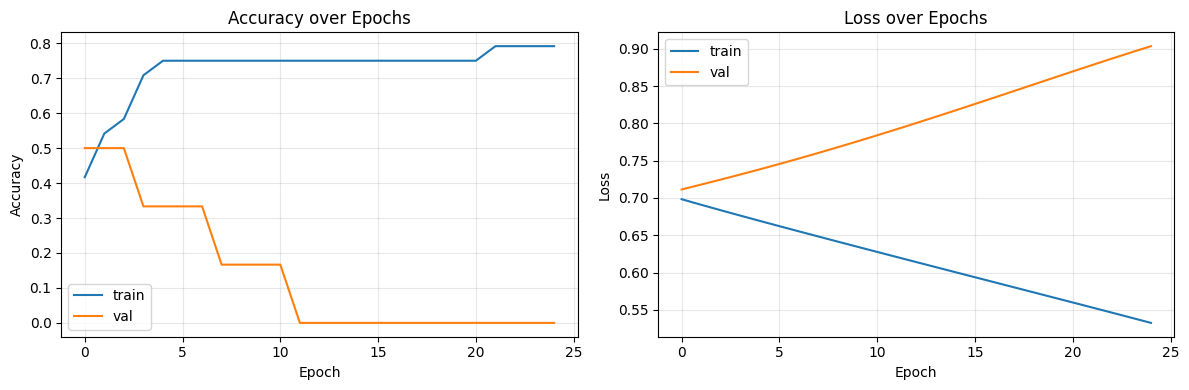

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

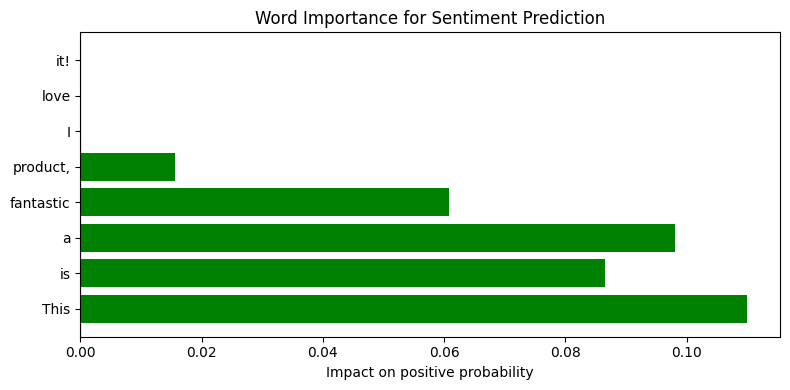

In [74]:
def score_words(sentence, model, vectorizer):
    words = sentence.split()
    vocab = vectorizer.get_vocabulary()
    scores = {}

    for word in words:
        with_word = vectorizer([sentence]).numpy()
        without_word = vectorizer([" ".join(w for w in words if w != word)]).numpy()

        p_with = model.predict(with_word, verbose=0)[0][0]
        p_without = model.predict(without_word, verbose=0)[0][0]

        scores[word] = p_with - p_without

    return scores

sentence = "This is a fantastic product, I love it!"
scores = score_words(sentence, model, vectorizer)

words = list(scores.keys())
values = list(scores.values())
colors = ['green' if v > 0 else 'red' for v in values]

plt.figure(figsize=(8, 4))
plt.barh(words, values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Word Importance for Sentiment Prediction')
plt.xlabel('Impact on positive probability')
plt.tight_layout()
plt.show()

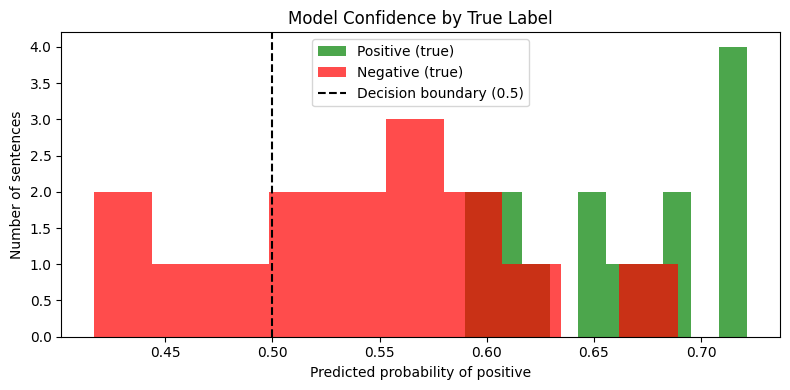

In [75]:
probs = model.predict(X, verbose=0).flatten()

pos_probs = probs[y == 1]
neg_probs = probs[y == 0]

plt.figure(figsize=(8, 4))
plt.hist(pos_probs, bins=10, alpha=0.7, label='Positive (true)', color='green')
plt.hist(neg_probs, bins=10, alpha=0.7, label='Negative (true)', color='red')
plt.axvline(0.5, color='black', linestyle='--', label='Decision boundary (0.5)')
plt.xlabel('Predicted probability of positive')
plt.ylabel('Number of sentences')
plt.title('Model Confidence by True Label')
plt.legend()
plt.tight_layout()
plt.show()